#### Polytope simplified use case 

In this notebook we will set uo the authentication with the DestinE platform and store the API key in `~/.polytopeapirc`.  

**Note**: An extensive set of examples can be found in this [github repository](https://github.com/destination-earth-digital-twins/polytope-examples/tree/main/climate-dt). 

In [45]:
# Run the authentication script — you will be prompted for your DESP username and password
# %run ../../desp-authentication.py
# Add alternative authentication

In [3]:
# Verify the key was stored
import os
keyfile = os.path.expanduser('~/.polytopeapirc')
if os.path.isfile(keyfile):
    print(f'Key stored in {keyfile}')
else:
    print('WARNING: key file not found — authentication may have failed')

Key stored in /home/aleon/.polytopeapirc


Now that your API key is configured, we should be able to access the data. For simplicity we use here only the output of 'IFS-FESOM' for the year 1990 and plot the global map. 

In [ ]:
import matplotlib.pyplot as plt
import healpy as hp
import earthkit.data
import xarray as xr
import numpy as np

In [44]:


def build_clmn_request(model, experiment, years, param,
                        resolution='standard', realization='1'):
    """Build a Polytope request dict for the clmn (monthly) stream.

    years can be a single int or an iterable of ints. Multiple years
    are joined with '/' so Polytope returns them all in one request.
    """
    if isinstance(years, (int, np.integer)):
        year_str = str(years)
    else:
        year_str = '/'.join(str(y) for y in years)

    return {
        "class": "d1",
        "dataset": "climate-dt",
        "type": "fc",
        "expver": "0001",
        "generation": "2",
        "realization": realization,
        "activity": 'baseline',
        "experiment": experiment,
        "model": model.upper(),
        "param": param,
        "levtype": "sfc",
        "resolution": resolution,
        "stream": "clmn",
        "year": year_str,
        "month": "1/2/3",
    }


In [ ]:
# --- Configuration ---
PARAM = 'avg_2t'
PARAM_NAME = '2m temperature'
MODELS = ['IFS-FESOM']#'IFS-NEMO', ICON
RESOLUTION = 'standard'
STORE_DATA = True          # Set True to cache NetCDF files to DATA_DIR
DATA_DIR = './data'

# Historical period
HIST_YEARS = range(1990, 1991)
HIST_EXPERIMENT = 'hist'        # activity: baseline

# Earthkit cache configuration — prevents unbounded cache growth
earthkit.data.config.set("cache-policy", "temporary")
earthkit.data.config.set("maximum-cache-size", "2G")
# Historical period
HIST_YEARS = range(1990, 1991)
HIST_EXPERIMENT = 'hist'        # activity: baseline
data_models = []
for model in MODELS:
    print(model)
    request = build_clmn_request(model, 
                                 HIST_EXPERIMENT, 
                                 HIST_YEARS, 
                                 PARAM,
                                 RESOLUTION, 
                                 '1')
    data_models.append(
        earthkit.data.from_source(
        "polytope", 
        "destination-earth", 
        request,
        address="polytope.lumi.apps.dte.destination-earth.eu", 
        stream=False
        )
    )

IFS-FESOM


2026-08-13 13:49:35 - INFO - Key read from /home/aleon/.polytopeapirc
2026-08-13 13:49:35 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'month: 1/2/3\n'
            'param: avg_2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            "year: '1990'\n",
 'verb': 'retrieve'}
2026-08-13 13:49:35 - INFO - Polytope user key found in session cache for user aleon
2026-08-13 13:49:51 - INFO - Request accepted. Please poll ./01ejwrk983152yy007vtke2xad for status
2026-08-13 13:49:51 - INFO - Polytope user key found in session cache for user aleon
2026-08-13 13:49:51 - INFO - Checking request status (01ejwrk983152yy007vtke2xad)...
2026-08-13 13:50:06 - INFO - The curren

In [33]:
ds = data_models[0].to_xarray(engine="cfgrib")
ds_JFM = ds.mean(dim='time')['avg_2t'].isel(heightAboveGround=0,step=0)


<Figure size 1800x500 with 0 Axes>

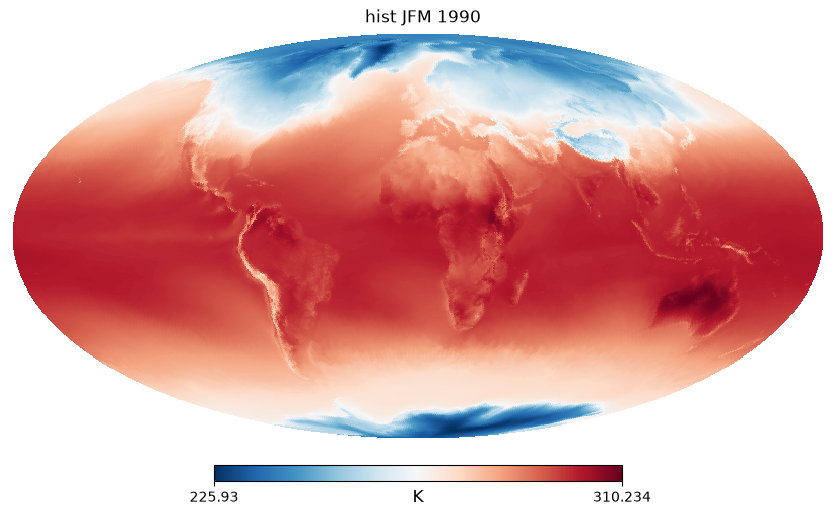

In [40]:
# Plot climate change signal for each model
fig = plt.figure(figsize=(18, 5))
for i, model in enumerate(MODELS):
    hp.mollview(
        ds_JFM, 
        nest=True,
        flip='geo',
        cmap='RdBu_r', 
        title=
              f'  {HIST_EXPERIMENT} JFM {HIST_YEARS[0]}',
        unit='K',
    )